# Data Import
After cleaning and transforming the raw data with dbt, we can import the data directly from PostgreSQL.

In [1]:
import pandas as pd
from sqlalchemy import create_engine

In [14]:
# 1. Setup local Postgres connection string
DATABASE_URL = "postgresql://Kabir@localhost:5432/resilience_gap"

# 2. Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# 3. Load the mart table straight into a Pandas DataFrame
query = "SELECT * FROM dbt_dev.mart_merge"
ess_survey = pd.read_sql(query, con=engine)

print(f"Data loaded. Shape: {ess_survey.shape}")

Data loaded. Shape: (14329, 64)


# Investigating Data
Reorder columns after merge (easier to do with pandas than with SQL or dbt), creating vectors of associated variables. Also, check missingness proportions and distribution of survey weights (in the dbt stage we intentionally implemented Winsorization to avoid super heavily weighted individuals skewing models).

In [15]:
# Review columns in data
ess_survey.columns

Index(['ess11_region_code', 'nuts1', 'nuts1_gdp_euro_2022',
       'nuts1_gdp_pct_eu_avg_2022', 'nuts1_unemployment_rate_pct_2022',
       'nuts1_net_migration_2022', 'nuts1_pop_density_2022',
       'nuts1_pop_growth_rate_2022', 'delta_gdp_pct_eu_avg_5yr',
       'delta_unemployment_pct_5yr', 'delta_net_migration_2yr',
       'delta_pop_growth_rate_5yr', 'respondent_id', 'country_code',
       'nuts_level', 'nuts_region', 'model_analysis_wt', 'age', 'ppltrst',
       'trstprl', 'trstlgl', 'trst_pol_parties', 'trst_euro_parl',
       'left_right_alignment', 'eu_role', 'sat_life', 'sat_economy', 'sat_gov',
       'sat_demo', 'immigration_impact_economy', 'immigration_impact_culture',
       'immigrants_impact_country', 'country_attachment', 'eur_attachment',
       'how_religious', 'hh_income_decile', 'imp_treat_ppl_equally',
       'imp_understand_diff_ppl', 'imp_govt_strength', 'polintr',
       'personal_say_govt', 'personal_influence_politics', 'vote_yn',
       'govt_role_income_in

In [ ]:
# 1. Identifiers & Weights
identifiers_and_weights = [
    "respondent_id",
    "country_code",
    "ess11_region_code",
    "nuts_region",
    "nuts1",
    "nuts_level",
    "model_analysis_wt",
]

# 2. Main Target & Behavioral Voting Variables
voting_and_targets = [
    "rw_populist_vote",  # Clear primary target variable
    "voting_behavior_manifest",  # The categorical flag we created
    "vote_yn",
    "vote_fr",
    "vote_de2",
    "vote_gr",
    "vote_it",
    "vote_pl",
    "vote_es",
    "vote_se",
]

# 3. Individual Demographics & Socio-Economics
demographics = [
    "gender",
    "age",
    "citizen",
    "identify_ethnic_majority",
    "educ_attainment",
    "educ_attainment_father",
    "educ_attainment_mother",
    "intergen_educational_mobility",
    "hh_income_decile",
    "hh_income_comfort",
    "unemp_over_12_mos_ever",
    "unemp_last_5_years",
    "how_religious",
]

# 4. Political Attitudinal & Trust Metrics (The 11-point & Short Scales)
political_attitudes = [
    "left_right_alignment",
    "polintr",
    "personal_say_govt",
    "personal_influence_politics",
    "ppltrst",
    "trstprl",
    "trstlgl",
    "trst_pol_parties",
    "trst_euro_parl",
    "sat_life",
    "sat_economy",
    "sat_gov",
    "sat_demo",
    "govt_role_income_inequality",
]

# 5. Societal & International Attitudes (Immigration, EU, Values)
societal_attitudes = [
    "eu_role",
    "country_attachment",
    "eur_attachment",
    "immigration_impact_economy",
    "immigration_impact_culture",
    "immigrants_impact_country",
    "allow_diverse_immigrants",
    "imp_treat_ppl_equally",
    "imp_understand_diff_ppl",
    "imp_govt_strength",
]

# 6. Macro Regional Context & Shocks (NUTS1 level)
regional_context = [
    "nuts1_gdp_euro_2022",
    "nuts1_gdp_pct_eu_avg_2022",
    "nuts1_unemployment_rate_pct_2022",
    "nuts1_net_migration_2022",
    "nuts1_pop_density_2022",
    "nuts1_pop_growth_rate_2022",
    "delta_gdp_pct_eu_avg_5yr",
    "delta_unemployment_pct_5yr",
    "delta_net_migration_2yr",
    "delta_pop_growth_rate_5yr",
]

# --- COMBINE ALL BLOCKS ---
ordered_columns = (
    identifiers_and_weights
    + voting_and_targets
    + demographics
    + political_attitudes
    + societal_attitudes
    + regional_context
)

# 3. Reorders the dataframe columns in place
ess_survey = ess_survey[ordered_columns]

print(f"Shape: {ess_survey.shape}") # Check no columns forgotten. Previous shape was (14329, 64)

Shape: (14329, 64)


In [5]:
# Check the statistical distribution of active weights
print(ess_survey['model_analysis_wt'].describe())

count    14329.000000
mean         1.742354
std          1.216844
min          0.038882
25%          0.613952
50%          1.705909
75%          2.419199
max          5.000000
Name: model_analysis_wt, dtype: float64


In [21]:
# 1. Calculate the percentage of missing values per country for every column
missing_report = (
    ess_survey.groupby('country_code')
    .apply(lambda x: (x.isnull().sum() / len(x)) * 100)
    # Drop the grouping column from the axis to avoid redundancy
    .drop(columns=['country_code'], errors='ignore')
)

# 2. Transpose the results so columns are rows, making it incredibly easy to scroll through
missing_report_pivoted = missing_report.T

# 3. Display the full matrix (preventing pandas from clipping rows)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(missing_report_pivoted.round(2))

country_code                          DE      ES      FR      GR      IT  \
respondent_id                       0.00    0.00    0.00    0.00    0.00   
ess11_region_code                   0.00    0.00    0.00    0.00    0.00   
nuts_region                         0.00    0.00    0.00    0.00    0.00   
nuts1                               0.00    0.00    0.00    0.00    0.00   
nuts_level                          0.00    0.00    0.00    0.00    0.00   
model_analysis_wt                   0.00    0.00    0.00    0.00    0.00   
rw_populist_vote                   32.52   43.22   53.42   33.48   56.68   
voting_behavior_manifest            0.00    0.00    0.00    0.00    0.00   
vote_yn                             0.21    0.11    1.81    0.07    2.37   
vote_fr                           100.00  100.00   53.42  100.00  100.00   
vote_de2                           32.52  100.00  100.00  100.00  100.00   
vote_gr                           100.00  100.00  100.00   33.48  100.00   
vote_it     

In [31]:
# Group by country and region, and get the respondent count for each
region_counts = (
    ess_survey.groupby(["country_code", "nuts1"])["respondent_id"]
    .count()
    .reset_index(name="sample_size")
)

# Sort from highest to lowest sample size
region_counts_sorted = region_counts.sort_values(
    by="sample_size", ascending=False
)

region_counts_sorted

,country_code,nuts1,sample_size
34,GR,EL3,923
38,IT,ITC,883
36,GR,EL5,795
37,GR,EL6,752
39,IT,ITF,618
8,DE,DEA,615
51,SE,SE2,538
42,IT,ITI,537
41,IT,ITH,495
19,ES,ES5,447


# Preliminary Visualizations

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
# Set theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 13,
    'legend.title_fontsize': 11
})

/var/folders/8x/_6srvv510170nx5xz7b75jp00000gn/T/ipykernel_24994/3361411462.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


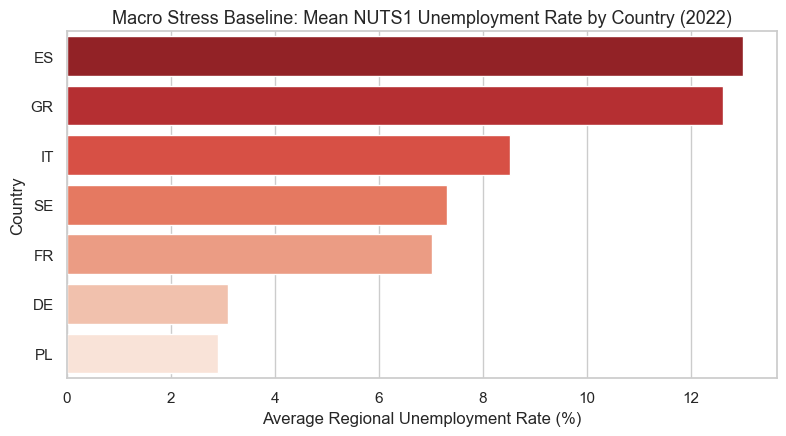

In [8]:
# Unemployment
fig, ax = plt.subplots(figsize=(8, 4.5))

unemp_by_country = (
    ess_survey.groupby('country_code')['nuts1_unemployment_rate_pct_2022']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=unemp_by_country, 
    x='nuts1_unemployment_rate_pct_2022', 
    y='country_code', 
    palette='Reds_r',
    ax=ax
)
ax.set_title('Macro Stress Baseline: Mean NUTS1 Unemployment Rate by Country (2022)')
ax.set_xlabel('Average Regional Unemployment Rate (%)')
ax.set_ylabel('Country')
plt.tight_layout()
#plt.savefig('01_macro_unemployment_by_country.png', dpi=300)



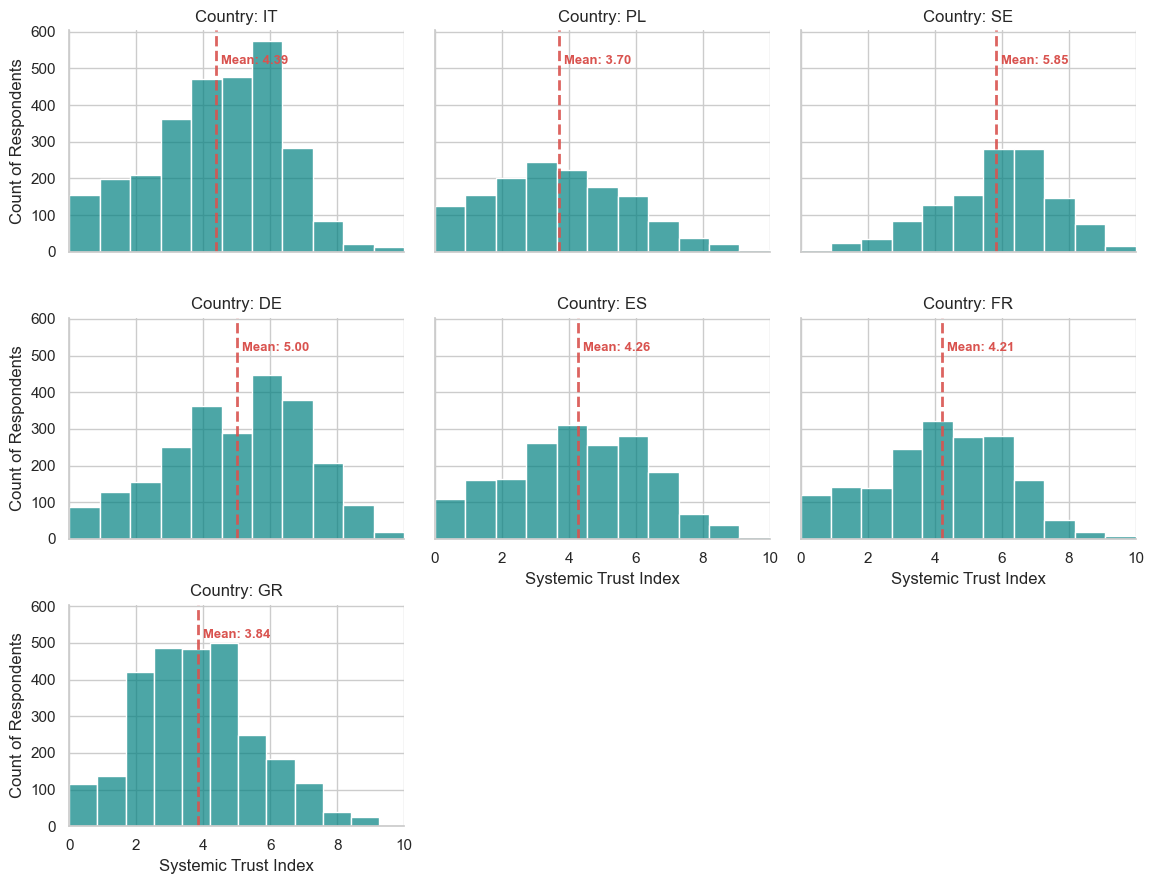

In [25]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

trust_vectors = ['trstprl', 'trstlgl', 'trst_pol_parties', "trst_euro_parl"]

# 1. Create a clean working copy of the dataset containing only essential columns
clean_trust_df = ess_survey[['country_code', 'nuts1'] + trust_vectors].copy()

# 2. Convert ESS missing codes to NaN
for col in trust_vectors:
    clean_trust_df[col] = pd.to_numeric(clean_trust_df[col], errors='coerce')
    clean_trust_df.loc[clean_trust_df[col] > 10, col] = np.nan

# 3. Calculate the index mean and drop rows where all three are missing
clean_trust_df['systemic_trust_index'] = clean_trust_df[trust_vectors].mean(axis=1)
clean_trust_df = clean_trust_df.dropna(subset=['systemic_trust_index'])

# 4. Define a custom function to calculate and draw the mean line per facet
def draw_mean_line(data, **kwargs):
    mean_val = data['systemic_trust_index'].mean()
    ax = plt.gca()
    
    # Draw the dashed vertical line
    ax.axvline(mean_val, color='#d9534f', linestyle='--', linewidth=2, alpha=0.9)
    
    # Annotate the numerical mean value
    # ax.get_xaxis_transform() locks the Y coordinate to a relative scale (0 = bottom, 1 = top)
    # This ensures the text always sits perfectly at 85% height regardless of respondent counts
    ax.text(
        x=mean_val + 0.15, 
        y=0.85, 
        s=f'Mean: {mean_val:.2f}', 
        transform=ax.get_xaxis_transform(), 
        color='#d9534f', 
        weight='bold', 
        fontsize=9.5
    )

# 5. Initialize the FacetGrid (This will dynamically accommodate your 7 countries)
g = sns.FacetGrid(
    clean_trust_df, 
    col="country_code", 
    col_wrap=3, 
    height=3, 
    aspect=1.3
)

# 6. Map the baseline histograms onto the grid
g.map_dataframe(
    sns.histplot, 
    x="systemic_trust_index", 
    bins=11, 
    color="teal", 
    alpha=0.7
)

# 7. Map our custom mean-line function on top of the histograms
g.map_dataframe(draw_mean_line)

# 8. Polish layout and axes boundaries
g.set_axis_labels("Systemic Trust Index", "Count of Respondents")
g.set_titles(col_template="Country: {col_name}")

for ax in g.axes.flat:
    ax.set_xlim(0, 10)
    ax.set_xticks([0, 2, 4, 6, 8, 10])

plt.tight_layout()
#plt.savefig('02_systemic_trust_index_faceted_with_mean.png', dpi=300)

/var/folders/8x/_6srvv510170nx5xz7b75jp00000gn/T/ipykernel_24994/967284003.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


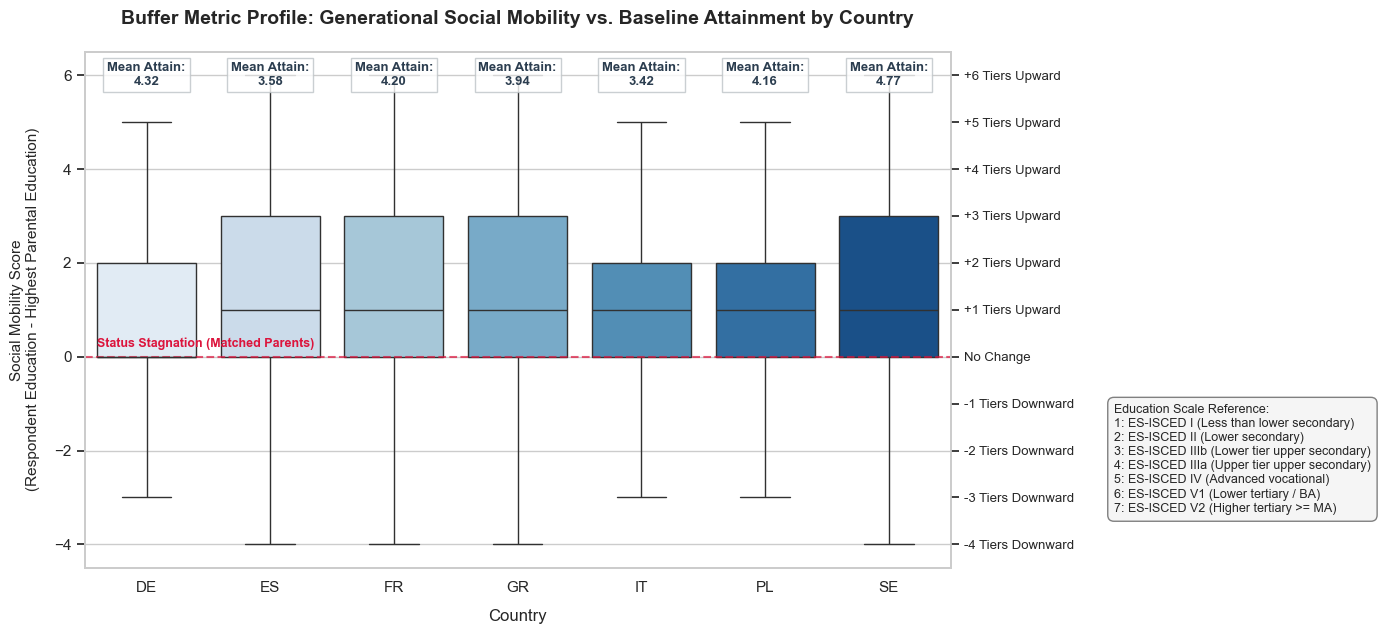

In [20]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

# 1. Define the education level codebook for visual context
education_codebook = {
    1: "ES-ISCED I (Less than lower secondary)",
    2: "ES-ISCED II (Lower secondary)",
    3: "ES-ISCED IIIb (Lower tier upper secondary)",
    4: "ES-ISCED IIIa (Upper tier upper secondary)",
    5: "ES-ISCED IV (Advanced vocational)",
    6: "ES-ISCED V1 (Lower tertiary / BA)",
    7: "ES-ISCED V2 (Higher tertiary >= MA)",
}

# 2. Sort countries sequentially by median mobility score
country_mobility_order = (
    ess_survey.groupby("country_code")["intergen_educational_mobility"]
    .median()
    .sort_values()
    .index
)

# 3. Compute the baseline MEAN educational attainment per country
# We use 'educ_attainment' (the respondent's clean, non-zero education column)
country_mean_attainment = (
    ess_survey.groupby("country_code")["educ_attainment"].mean().to_dict()
)

# 4. Render the clean boxplot
fig, ax1 = plt.subplots(figsize=(11, 6.5))  # Adjusted height slightly for annotations

sns.boxplot(
    data=ess_survey,
    x="country_code",
    y="intergen_educational_mobility",
    order=country_mobility_order,
    palette="Blues",
    ax=ax1,
    showfliers=False,
)

# 5. Format the primary Y-axis (The Relative Scale)
ax1.set_title(
    "Buffer Metric Profile: Generational Social Mobility vs. Baseline Attainment by Country",
    fontsize=14,
    pad=20,
    weight="bold",
)
ax1.set_xlabel("Country", fontsize=12, labelpad=10)
ax1.set_ylabel(
    "Social Mobility Score\n(Respondent Education - Highest Parental Education)",
    fontsize=11,
    labelpad=10,
)

# Add a prominent horizontal baseline at 0 to explicitly divide Upward vs Downward
ax1.axhline(0, color="crimson", linestyle="--", linewidth=1.5, alpha=0.7)
ax1.text(
    -0.4,
    0.2,
    "Status Stagnation (Matched Parents)",
    color="crimson",
    fontsize=9,
    weight="bold",
)

# 6. Dynamically add the Mean Baseline Attainment labels at the top of the chart
# We find the top of the current Y-axis limit to place the labels uniformly
top_y_limit = ax1.get_ylim()[1]
annotation_y_position = top_y_limit - 0.5  # Position slightly below the very top edge

for i, country in enumerate(country_mobility_order):
    mean_val = country_mean_attainment.get(country, np.nan)
    if not pd.isna(mean_val):
        ax1.text(
            i,
            annotation_y_position,
            f"Mean Attain:\n{mean_val:.2f}",
            ha="center",
            va="center",
            fontsize=9.5,
            weight="bold",
            color="#2c3e50",
            bbox=dict(
                boxstyle="square,pad=0.3",
                facecolor="white",
                edgecolor="#bdc3c7",
                alpha=0.8,
            ),
        )

# 7. Create a secondary Y-axis to map the magnitude of the shifts to the codebook
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())  # Keep scales perfectly aligned

# Generate tick marks showing the step distance
ticks = np.arange(int(ax1.get_ylim()[0]), int(ax1.get_ylim()[1]) + 1)
ax2.set_yticks(ticks)

# Format the labels dynamically to show what a change of +2 or -1 actually means
labels = []
for t in ticks:
    if t > 0:
        labels.append(f"+{t} Tiers Upward")
    elif t < 0:
        labels.append(f"{t} Tiers Downward")
    else:
        labels.append("No Change")

ax2.set_yticklabels(labels, fontsize=9.5)
ax2.grid(False)  # Turn off secondary grid lines to avoid visual noise

# 8. Add a textbook style footnote explaining the underlying scale hierarchy
codebook_text = "Education Scale Reference:\n" + "\n".join(
    [f"{k}: {v}" for k, v in education_codebook.items()]
)
plt.figtext(
    1.02,
    0.2,
    codebook_text,
    fontsize=9,
    fontfamily="sans-serif",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="whitesmoke", edgecolor="gray"),
)

plt.tight_layout()
# plt.savefig('03_social_mobility_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

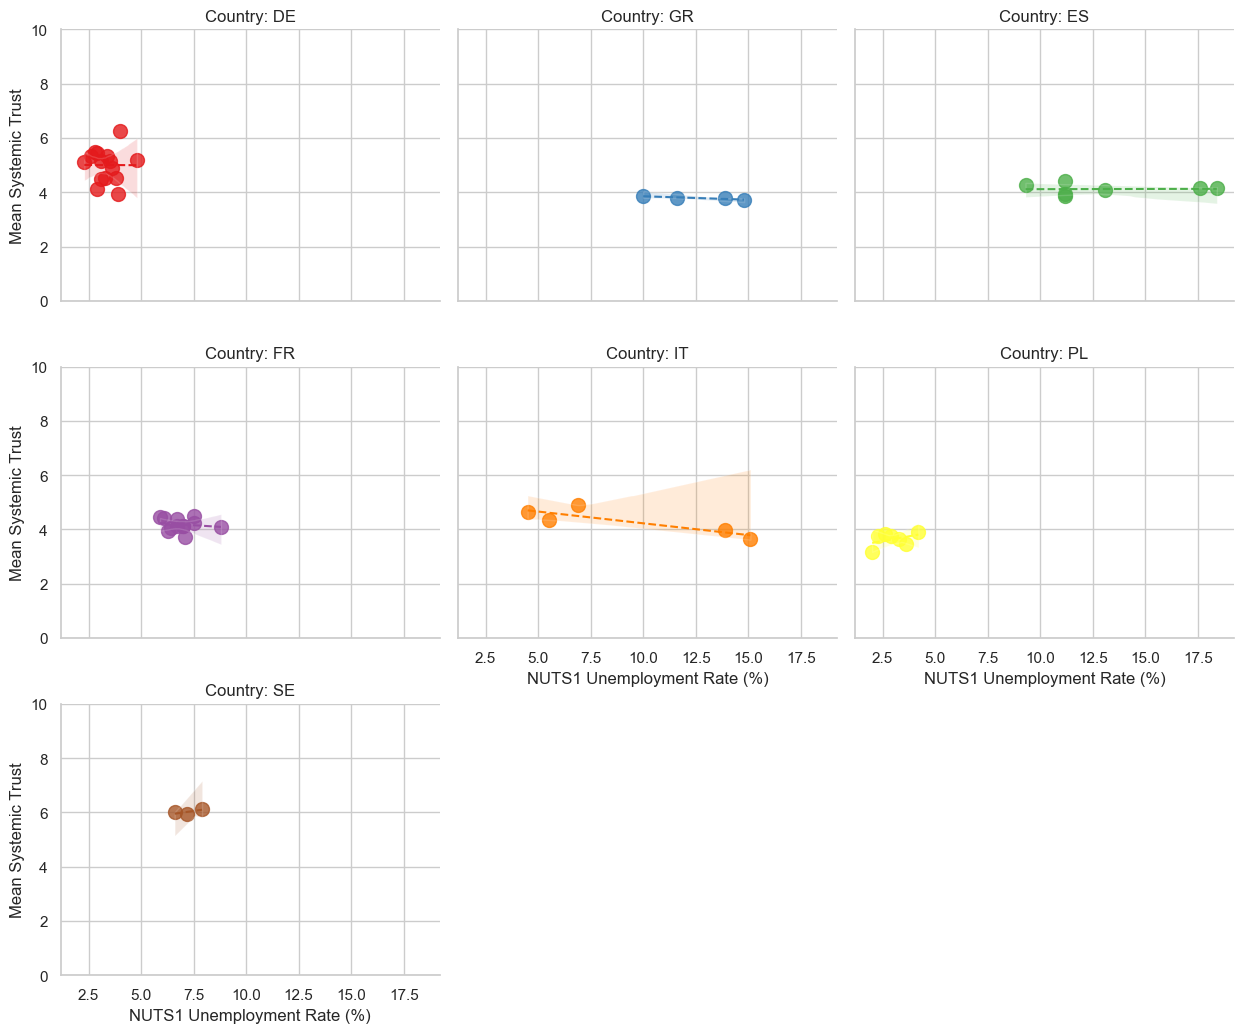

In [11]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

trust_vectors = ['trstprl', 'trstlgl', 'trst_pol_parties']

# 1. Create a clean working copy
clean_df = ess_survey.loc[
    :, ['country_code', 'nuts1', 'nuts1_unemployment_rate_pct_2022'] + trust_vectors
].copy()

# 2. Convert trust columns to numeric and strip out ESS placeholder codes
for col in trust_vectors:
    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')
    clean_df.loc[clean_df[col] > 10, col] = np.nan

# 3. Calculate clean individual trust index and drop missing records
clean_df['systemic_trust_index'] = clean_df[trust_vectors].mean(axis=1)
clean_df = clean_df.dropna(subset=['systemic_trust_index', 'nuts1_unemployment_rate_pct_2022'])

# 4. Aggregate individuals up to NUTS1 regional portfolios
regional_portfolios = clean_df.groupby(['nuts1', 'country_code']).agg({
    'nuts1_unemployment_rate_pct_2022': 'first',
    'systemic_trust_index': 'mean'
}).reset_index()

# 5. Use lmplot to facet by country and automatically draw trendlines
# col_wrap=3 organizes the 6 countries into a clean 2x3 grid matrix
g = sns.lmplot(
    data=regional_portfolios,
    x='nuts1_unemployment_rate_pct_2022',
    y='systemic_trust_index',
    col='country_code',
    col_wrap=3,
    hue='country_code',
    palette='Set1',
    height=3.5,
    aspect=1.2,
    scatter_kws={'s': 100, 'alpha': 0.8},
    line_kws={'linestyle': '--', 'linewidth': 1.5}
)

# 6. Polish layouts, titles, and label parameters across all subplots
g.set_axis_labels("NUTS1 Unemployment Rate (%)", "Mean Systemic Trust")
g.set_titles(col_template="Country: {col_name}")

# Enforce consistent formatting across axes limits
for ax in g.axes.flat:
    ax.set_ylim(0, 10) # Enforce strict 0-10 trust scale bounds
    # Dynamically expand X-limits slightly per plot to let points breathe, 
    # but keep them clean and readable.

plt.tight_layout()
#plt.savefig('04_regional_unemployment_vs_trust_faceted.png', dpi=300)

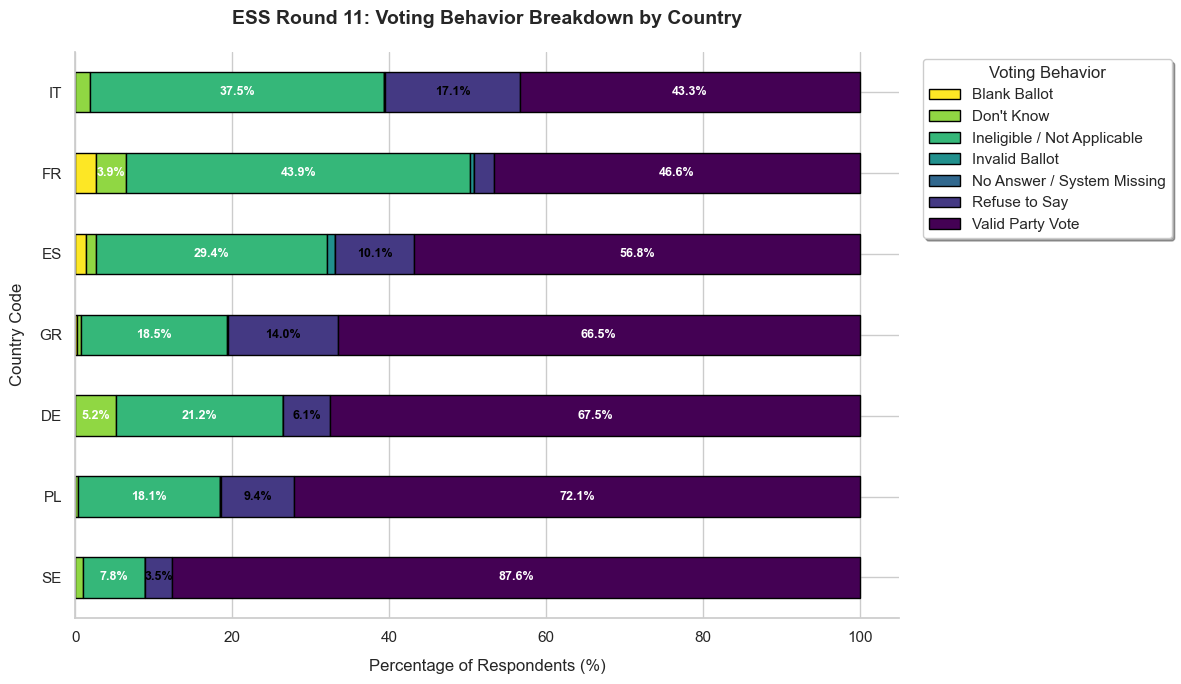

In [ ]:
# 1. Calculate percentages of voting behavior by country
# This normalizes the row counts so we can see relative proportions
cross_tab = pd.crosstab(
    ess_survey["country_code"],
    ess_survey["voting_behavior_manifest"],
    normalize="index",  # Calculates percentages per row (country)
) * 100

# 2. Sort the countries by a specific category to make the visual cleaner
# Sorting by 'Valid Party Vote' gives the chart a nice visual gradient
cross_tab = cross_tab.sort_values(by="Valid Party Vote", ascending=False)

# 3. Plotting the 100% Stacked Bar Chart
ax = cross_tab.plot(
    kind="barh", stacked=True, figsize=(12, 7), cmap="viridis_r", edgecolor="black"
)

# 4. Styling and Aesthetics
sns.despine()  # Cleans up the top and right borders
plt.title(
    "ESS Round 11: Voting Behavior Breakdown by Country",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xlabel("Percentage of Respondents (%)", fontsize=12, labelpad=10)
plt.ylabel("Country Code", fontsize=12, labelpad=10)

# Move the legend outside so it doesn't overlap the bars
plt.legend(
    title="Voting Behavior",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    shadow=True,
)

# 5. Add percentage labels directly onto the bars for scannability
# (Only adds labels for blocks larger than 3% to avoid messy overlap)
for p in ax.patches:
    width = p.get_width()
    if width > 3:  # Skip labeling tiny slices (like system slips)
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(
            x,
            y,
            f"{width:.1f}%",
            ha="center",
            va="center",
            color="white" if p.get_facecolor()[2] < 0.5 else "black",
            fontsize=9,
            weight="bold",
        )

plt.tight_layout()
plt.show()

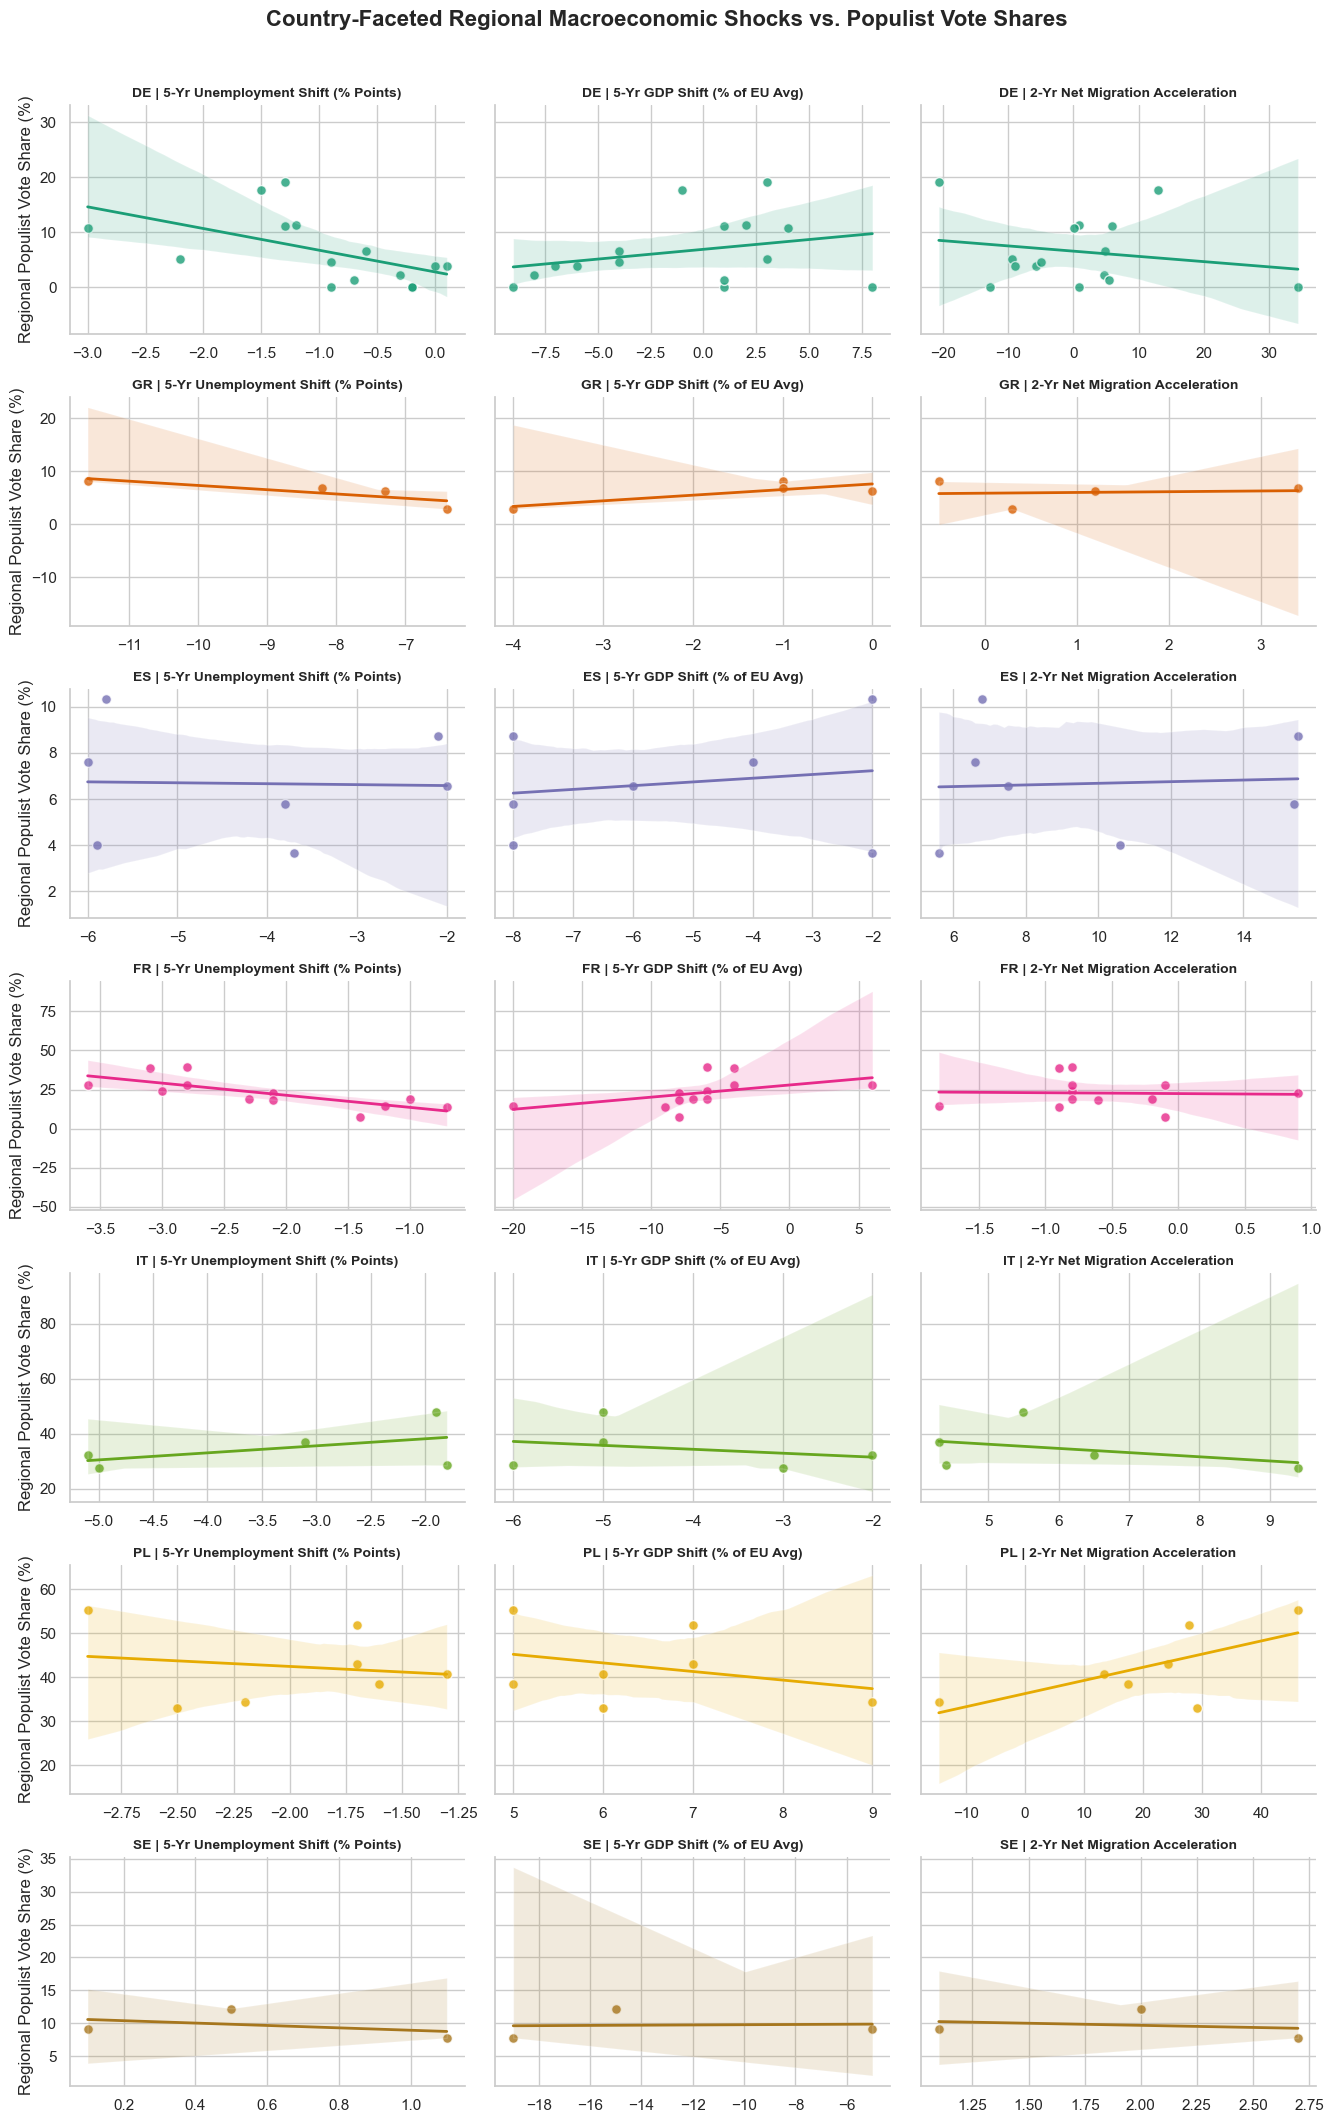

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set professional theme parameters
sns.set_theme(style="whitegrid")

# (Assuming df_regional and df_long are already created from the previous step)

# Render a grid where:
# - Each Row is a Country (7 rows)
# - Each Column is a Macro Shock Metric (3 columns)
g = sns.FacetGrid(
    df_long,
    row="country_code",
    col="macro_shock_metric",
    hue="country_code",  # Keeps the same country colors from your plot
    palette="Dark2",
    height=3,
    aspect=1.5,
    sharex=False,  # Essential: Metrics have different scales
    sharey="row",  # Changes y-axis scale per row so low-populist countries aren't flattened lines
)

# 1. Map the scatter points
g.map(plt.scatter, "shock_value", "populist_vote_pct", alpha=0.8, edgecolor="w", s=50)

# 2. Map distinct linear regression trendlines for EACH individual country block
g.map(
    sns.regplot,
    "shock_value",
    "populist_vote_pct",
    scatter=False,
    line_kws={"linestyle": "-", "linewidth": 2},
)

# 3. Styling & Labels
g.set_titles(template="{row_name} | {col_name}", weight="bold", size=10)
g.set_axis_labels("", "Regional Populist Vote Share (%)")

# Add a professional overall title above the subplots
plt.suptitle(
    "Country-Faceted Regional Macroeconomic Shocks vs. Populist Vote Shares",
    fontsize=16,
    weight="bold",
    y=1.01,
)

plt.tight_layout()
plt.show()

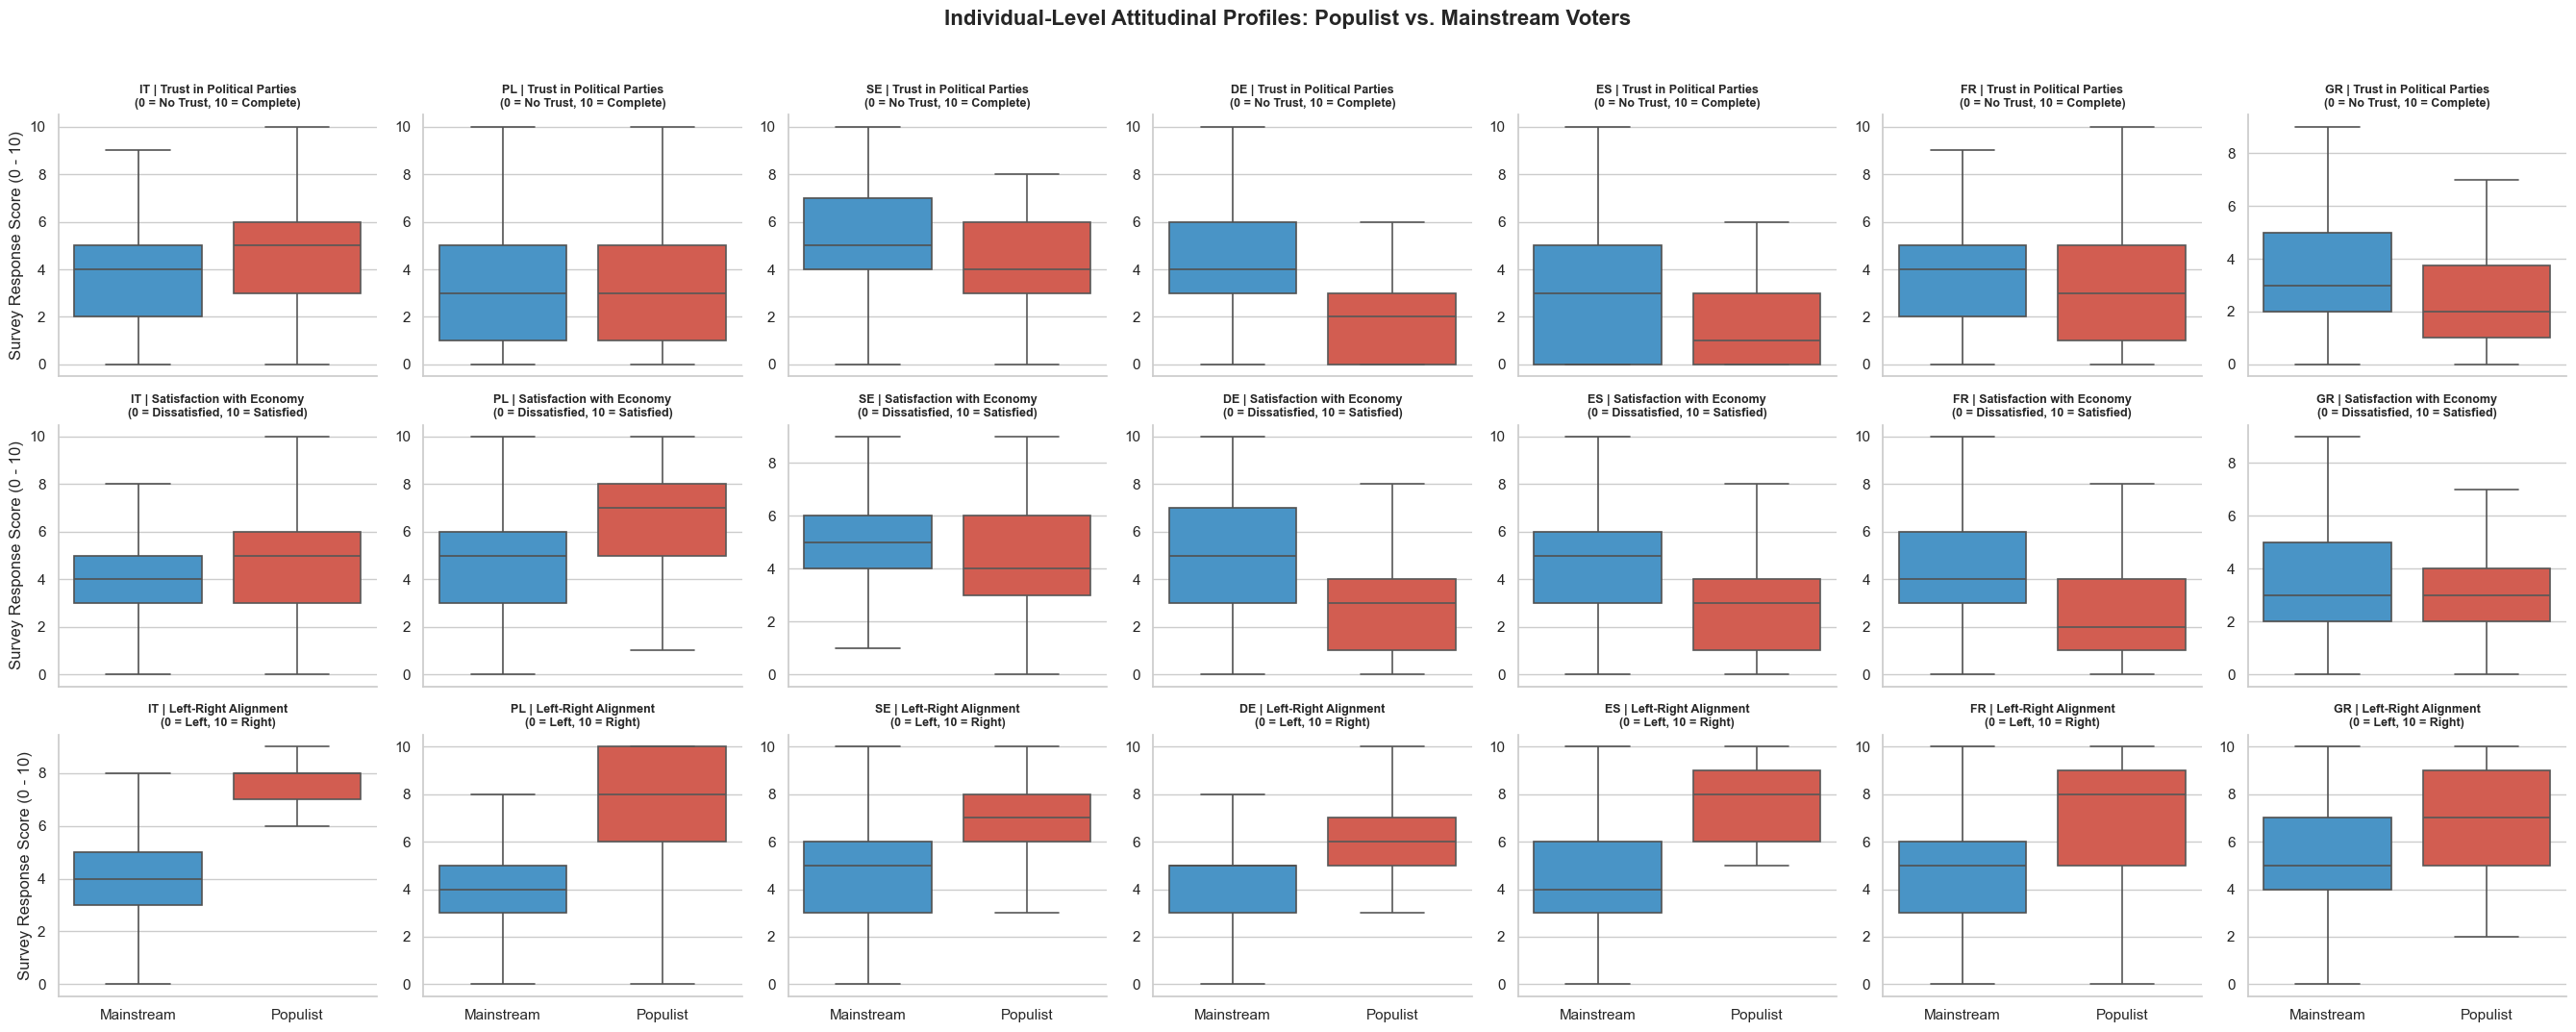

In [33]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

# 1. Select the attitudinal features we want to profile
attitudinal_vars = ["trst_pol_parties", "sat_economy", "left_right_alignment"]

# Filter out rows where our target or features are missing
df_clean = ess_survey.dropna(subset=["rw_populist_vote"] + attitudinal_vars).copy()

# Ensure target is treated as a clean categorical string for plotting
df_clean["Voter Type"] = df_clean["rw_populist_vote"].map(
    {1: "Populist", 0: "Mainstream"}
)

# 2. Melt data to long format for Tidyverse-style faceting
df_attitudes_long = pd.melt(
    df_clean,
    id_vars=["respondent_id", "country_code", "Voter Type"],
    value_vars=attitudinal_vars,
    var_name="Attitude_Metric",
    value_name="Score",
)

# Make the metric names beautiful for the plot row headers
metric_labels = {
    "trst_pol_parties": "Trust in Political Parties\n(0 = No Trust, 10 = Complete)",
    "sat_economy": "Satisfaction with Economy\n(0 = Dissatisfied, 10 = Satisfied)",
    "left_right_alignment": "Left-Right Alignment\n(0 = Left, 10 = Right)",
}
df_attitudes_long["Attitude_Metric"] = df_attitudes_long["Attitude_Metric"].map(
    metric_labels
)

# 3. Render the FacetGrid Matrix
# Row = The psychological metric, Col = The country
g = sns.FacetGrid(
    df_attitudes_long,
    row="Attitude_Metric",
    col="country_code",
    hue="Voter Type",
    palette={"Mainstream": "#3498db", "Populist": "#e74c3c"},  # Clean Blue vs. Populist Red
    height=3.5,
    aspect=1.1,
    sharey=False,  # While all are 0-10, letting y-limits breathe handles padding cleanly
)

# Map the boxplots to the grid
g.map(
    sns.boxplot,
    "Voter Type",
    "Score",
    order=["Mainstream", "Populist"],
    showfliers=False,  # Hides extreme outliers to focus on the median/IQR boxes
    linewidth=1.2,
)

# 4. Styling & Layout Polish
g.set_titles(template="{col_name} | {row_name}", weight="bold", size=9)
g.set_axis_labels("", "Survey Response Score (0 - 10)")

# Adjust headers to prevent overlapping text
plt.suptitle(
    "Individual-Level Attitudinal Profiles: Populist vs. Mainstream Voters",
    fontsize=16,
    weight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

/var/folders/8x/_6srvv510170nx5xz7b75jp00000gn/T/ipykernel_24994/4173931100.py:90: UserWarning: Glyph 9664 (\N{BLACK LEFT-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8x/_6srvv510170nx5xz7b75jp00000gn/T/ipykernel_24994/4173931100.py:90: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout()
/opt/miniconda3/envs/spiced/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9664 (\N{BLACK LEFT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/spiced/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


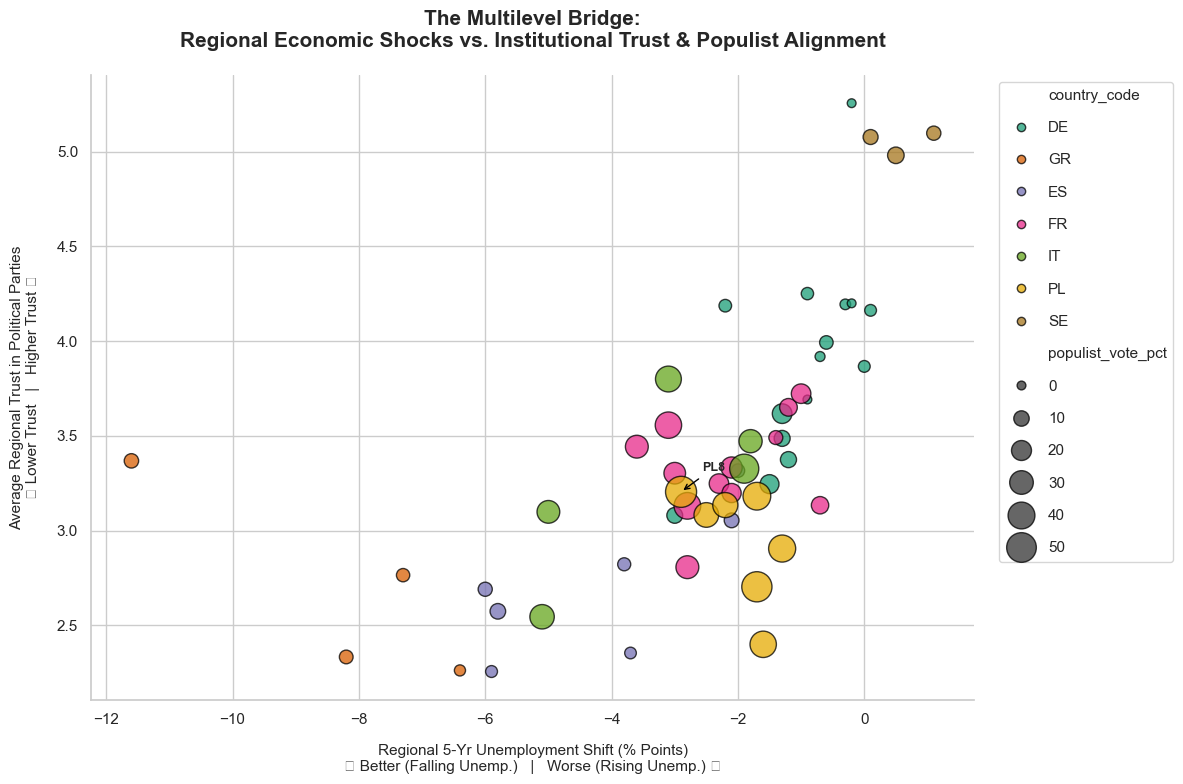

In [35]:
# Set professional theme parameters
sns.set_theme(style="whitegrid")

# ==========================================
# 1. AGGREGATE TO NUTS 1 REGIONAL LEVEL
# ==========================================
aggregation_rules = {
    # Y-Axis: Average political trust within the region
    "trst_pol_parties": "mean",
    # X-Axis: The 5-year structural economic shock
    "delta_unemployment_pct_5yr": "first",
    # Bubble Size: Target variable (% populist vote share)
    "rw_populist_vote": "mean",
    # Bubble Color: Track country clusters
    "country_code": "first",
}

df_bridge = ess_survey.groupby("nuts1").agg(aggregation_rules).dropna().reset_index()

# Convert target to percentage for clear labeling
df_bridge["populist_vote_pct"] = df_bridge["rw_populist_vote"] * 100

# ==========================================
# 2. RENDER THE MULTILEVEL BUBBLE CHART
# ==========================================
plt.figure(figsize=(12, 8))

# Define bubble scaling boundaries (min size=40, max size=500 based on vote share)
sns.scatterplot(
    data=df_bridge,
    x="delta_unemployment_pct_5yr",
    y="trst_pol_parties",
    hue="country_code",
    size="populist_vote_pct",
    sizes=(40, 500),
    palette="Dark2",
    alpha=0.75,
    edgecolor="black",
    linewidth=1,
)

# ==========================================
# 3. GRAPH STYLING & INTUITION ANCHORS
# ==========================================
plt.title(
    "The Multilevel Bridge:\nRegional Economic Shocks vs. Institutional Trust & Populist Alignment",
    fontsize=15,
    weight="bold",
    pad=20,
)
plt.xlabel(
    "Regional 5-Yr Unemployment Shift (% Points)\n◀ Better (Falling Unemp.)   |   Worse (Rising Unemp.) ▶",
    fontsize=11,
    labelpad=12,
)
plt.ylabel(
    "Average Regional Trust in Political Parties\n◀ Lower Trust   |   Higher Trust ▶",
    fontsize=11,
    labelpad=12,
)

# Clean up layout and legends
sns.despine()

# Organize the legends cleanly on the right flank so they don't overlap the bubbles
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    markerscale=1,
    labelspacing=1.2,
)

# Optional: Label extreme standout regions directly on the plot
# (Finds the highest populist region to annotate it)
highest_populist_region = df_bridge.loc[df_bridge["populist_vote_pct"].idxmax()]
plt.annotate(
    highest_populist_region["nuts1"],
    xy=(
        highest_populist_region["delta_unemployment_pct_5yr"],
        highest_populist_region["trst_pol_parties"],
    ),
    xytext=(15, 15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
    fontsize=9,
    weight="bold",
)

plt.tight_layout()
plt.show()

# Regressions

In [37]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Isolate individual-level variables of interest
# We drop regional variables for this baseline to prevent cluster distortion
model_cols = [
    "rw_populist_vote",
    "intergen_educational_mobility",
    "educ_attainment",
    "trst_pol_parties",
    "sat_economy",
    "gender",
    "age",
    "country_code",
]
df_logit = ess_survey[model_cols].dropna()

# 2. Fit a baseline Logit model with country fixed-effects
# (C(country_code) automatically controls for national baseline shifts)
logit_formula = (
    "rw_populist_vote ~ intergen_educational_mobility + educ_attainment + "
    "trst_pol_parties + sat_economy + gender + age + C(country_code)"
)

logit_model = smf.logit(formula=logit_formula, data=df_logit).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.368240
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       rw_populist_vote   No. Observations:                 8282
Model:                          Logit   Df Residuals:                     8269
Method:                           MLE   Df Model:                           12
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.1740
Time:                        04:54:01   Log-Likelihood:                -3049.8
converged:                       True   LL-Null:                       -3692.1
Covariance Type:            nonrobust   LLR p-value:                9.772e-268
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -0.8990      0.247     -3.639      0.

In [38]:
# Create a clean dataset combining individual and regional layers
mixed_cols = [
    "rw_populist_vote",
    "trst_pol_parties",
    "intergen_educational_mobility",
    "delta_unemployment_pct_5yr",
    "delta_net_migration_2yr",
    "country_code",
    "nuts1",
]
df_mixed = ess_survey[mixed_cols].dropna()

# Fit a Mixed Effects model
# Fixed effects = Individual traits + Regional macro shocks
# Random effects = Random intercepts for countries to handle the color bands we saw in the EDA
mixed_formula = (
    "rw_populist_vote ~ trst_pol_parties + intergen_educational_mobility + "
    "delta_unemployment_pct_5yr + delta_net_migration_2yr"
)

mixed_model = smf.mixedlm(
    mixed_formula, data=df_mixed, groups=df_mixed["country_code"]
).fit()
print(mixed_model.summary())

                 Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    rw_populist_vote
No. Observations:     8367       Method:                REML            
No. Groups:           7          Scale:                 0.1175          
Min. group size:      769        Log-Likelihood:        -2955.8633      
Max. group size:      1821       Converged:             Yes             
Mean group size:      1195.3                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.200    0.056  3.572 0.000  0.090  0.310
trst_pol_parties              -0.011    0.002 -6.362 0.000 -0.015 -0.008
intergen_educational_mobility -0.003    0.002 -1.382 0.167 -0.007  0.001
delta_unemployment_pct_5yr    -0.005    0.003 -1.657 0.098 -0.011  0.